In [21]:
import numpy as np
from empiricaldist import Pmf
from scipy.stats import binom
import matplotlib.pyplot as plt

## 4.2 The Binomial Distribution

In [3]:
def make_binomial(n, p):
    """Make a binomial Pmf."""
    ks = np.arange(n+1)
    ps = binom.pmf(ks, n, p)
    return Pmf(ps, ks)


def prob_ge(pmf, threshold):
    """Probability of quantities greater than threshold."""
    ge = (pmf.qs >= threshold)
    total = pmf[ge].sum()
    return total


pmf_k = make_binomial(n=250, p=0.5)
pmf_k.prob_ge(140) + pmf_k.prob_le(110)

0.06642115124004336

## 4.3 Bayesian Estimation

<Axes: >

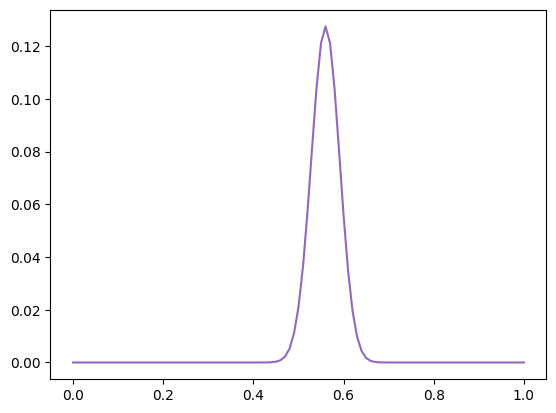

In [12]:
hypos = np.linspace(0, 1, 101)
prior = Pmf(1 / len(hypos), hypos)

likelihood_heads = hypos
likelihood_tails = 1 - hypos
likelihood = {
    'H': likelihood_heads,
    'T': likelihood_tails
}

dataset = 'H' * 140 + 'T' * 110
def update_euro(pmf, dataset):
    """Update pmf with a given sequence of H and T."""
    pmf = pmf.copy()
    for data in dataset:
        pmf *= likelihood[data]
    pmf.normalize()
    return pmf


posterior = update_euro(prior, dataset)
posterior.plot(label='140 heads out of 250', color='C4')

In [13]:
posterior.max_prob()

0.56

## 4.4 Triangle Prior

<Axes: >

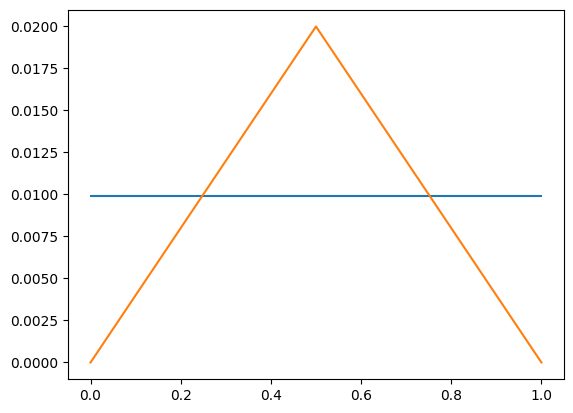

In [11]:
uniform_prior = Pmf(1 / len(hypos), hypos, name='uniform')

ramp_up = np.arange(50)
ramp_down = np.arange(50, -1, -1)
a = np.append(ramp_up, ramp_down)
triangle_prior = Pmf(a, hypos, name='triangle')
triangle_prior.normalize()

uniform_prior.plot()
triangle_prior.plot()

<Axes: >

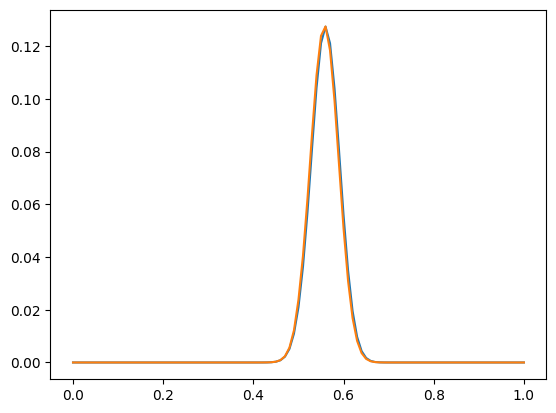

In [15]:
uniform_posterior = update_euro(uniform_prior, dataset)
triangle_posterior = update_euro(triangle_prior, dataset)
uniform_posterior.plot()
triangle_posterior.plot()

## 4.5 The Binomial Likelihood Function

In [16]:
def update_binomial(pmf, k, n):
    """Update pmf using the binomial distribution."""
    pmf = pmf.copy()
    ps = pmf.qs

    likelihood = binom.pmf(k, n, ps)
    pmf *= likelihood
    pmf.normalize()
    
    return pmf


uniform_prior2 = Pmf(1/len(hypos), hypos, name='uniform2')
uniform_posterior2 = update_binomial(uniform_prior2, 140, 250)
np.allclose(uniform_posterior, uniform_posterior2)

True

## 4.8 Exercises
#### 4.8.1 Exercise 1

<Axes: >

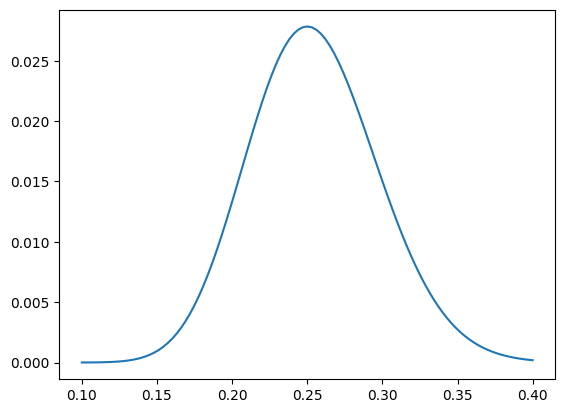

In [18]:
hypos = np.linspace(0.1, 0.4, 101)
prior = Pmf(1 / len(hypos), hypos)

average_prior = update_binomial(prior, 25, 100)
average_prior.plot()

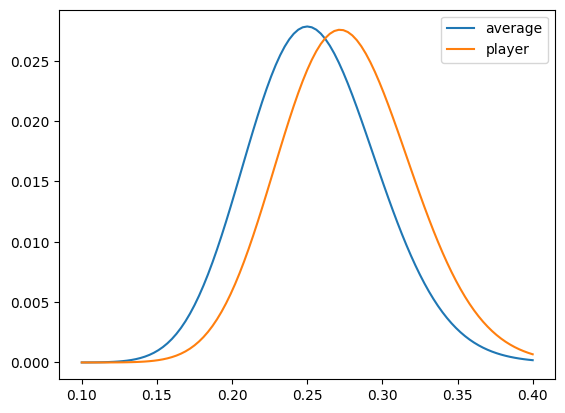

In [22]:
player_posterior = update_binomial(average_prior, 3, 3)

average_prior.plot(label='average')
player_posterior.plot(label='player')
plt.legend()

In [23]:
print('average:', average_prior.max_prob())
print('player:', player_posterior.max_prob())

average: 0.25
player: 0.271


### 4.8.2 Exercise 2

0.6


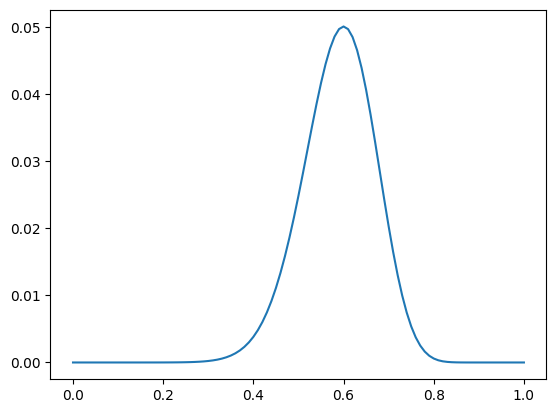

In [26]:
hypos = np.linspace(0, 1, 101)
prior = Pmf(1/len(hypos), hypos)

posterior = prior.copy()
likelihood = binom.pmf(80, 100, 0.5 + 0.5 * hypos)
posterior *= likelihood
posterior.normalize()

posterior.plot()
print(posterior.max_prob())